# L1.1 — The aircraft state

**Level 1 · Core · 30 minutes**

**Goal.** You can make one aircraft and read its state.

**Check at the end.** You can say what `trk` and `yaw` each mean, and you can name an aircraft where
the two are different.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. Make one aircraft

Use `create_aircraft`. It is the validated entry point. Give it a `Performance` first, then the
fields by keyword.

```python
create_aircraft(perf, *, id, lat, lon, trk, gs,
                bank=0.0, pos_ci95=0.0, vel_ci95=0.0,
                pos_ci95_declared=None, vel_ci95_declared=None)
```

| Field | Unit | What it is |
| --- | --- | --- |
| `id` | — | The identifier. It must be unique in the fleet. |
| `lat`, `lon` | deg | The position, WGS84. |
| `trk` | deg | The track over the ground. 0 is north, and the angle increases clockwise. |
| `gs` | m/s | The ground speed. |
| `bank` | deg | The roll angle. A multirotor keeps 0. |
| `pos_ci95`, `vel_ci95` | m, m/s | How accurate this receiver is, as a 95 % radial value. |
| `pos_ci95_declared`, `vel_ci95_declared` | m, m/s | What the aircraft broadcasts instead. `None` broadcasts the truth. |

In [1]:
import dataclasses

from opencdarr import M600, SMALL_FIXEDWING, AircraftState, create_aircraft

own = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0)

for f in dataclasses.fields(own):
    print(f"{f.name:<20} {str(getattr(own, f.name)):<12} {f.type}")

id                   OWN          str
lat                  52.0         float
lon                  4.0          float
trk                  0.0          float
gs                   10.0         float
yaw                  None         float | None
bank                 0.0          float
desired              None         DesiredVelocity | None
pos_ci95             0.0          float
vel_ci95             0.0          float
pos_ci95_declared    None         float | None
vel_ci95_declared    None         float | None
flight_time          0.0          float
distance_flown       0.0          float


## 2. Change a field

`AircraftState` is frozen. You cannot assign to a field. Use `dataclasses.replace` to make a new
state from an old one.

```python
faster = dataclasses.replace(own, gs=15.0)
```

This is not a style rule. A frozen state cannot alias its source, so a copy of a state can never
change when the original changes. The estimators keep many states at the same time, and this is what
makes that safe.

In [2]:
faster = dataclasses.replace(own, gs=15.0)
print(f"the original   gs = {own.gs} m/s")
print(f"the new state  gs = {faster.gs} m/s")

try:
    own.gs = 15.0
except Exception as exc:
    print(f"\ndirect assignment fails:  {type(exc).__name__}: {exc}")

the original   gs = 10.0 m/s
the new state  gs = 15.0 m/s

direct assignment fails:  FrozenInstanceError: cannot assign to field 'gs'


## 3. Set the nose apart from the direction of travel

`trk` is where the aircraft **goes**. `yaw` is where its nose **points**.

- `yaw=None` (the default) means the nose follows the track. Use this unless you need otherwise.
- A number means an independently controlled nose. A multirotor can go one way and point another. A
  camera-pointing mission needs this.
- A fixed-wing has no independent yaw. Its facing follows from its bank, so leave `yaw` at `None`.

`yaw` is state, not a derived value. Under wind it becomes the heading ψ, and its difference from
the track is the crab angle. Lesson L1.11 uses it that way.

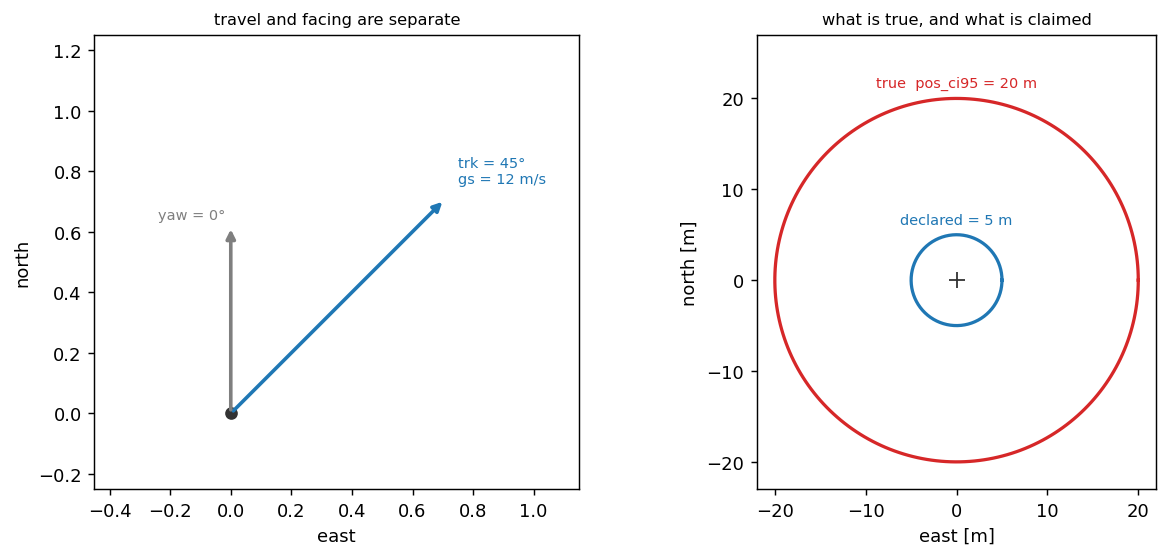

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, GREY, RED = "#1f77b4", "#7f7f7f", "#d62728"

# a multirotor that travels north-east while it points north
crab = dataclasses.replace(own, trk=45.0, gs=12.0, yaw=0.0)


def to_enu(deg: float, length: float) -> tuple[float, float]:
    """An aviation angle [deg] as an (east, north) vector of the given length."""
    r = np.radians(deg)
    return length * np.sin(r), length * np.cos(r)


fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(10.0, 4.4))

ve, vn = to_enu(crab.trk, 1.0)
ne, nn = to_enu(crab.yaw, 0.62)
ax_a.annotate("", (ve, vn), (0, 0), arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=2.0))
ax_a.annotate("", (ne, nn), (0, 0), arrowprops=dict(arrowstyle="-|>", color=GREY, lw=2.0))
ax_a.text(ve * 1.06, vn * 1.06, f"trk = {crab.trk:.0f}°\ngs = {crab.gs:.0f} m/s",
          color=BLUE, fontsize=8, va="bottom")
ax_a.text(ne * 1.1 - 0.24, nn * 1.02, f"yaw = {crab.yaw:.0f}°", color=GREY, fontsize=8, va="bottom")
ax_a.plot(0, 0, marker="o", ms=6, color="0.2")
ax_a.set_xlim(-0.45, 1.15)
ax_a.set_ylim(-0.25, 1.25)
ax_a.set_aspect("equal")
ax_a.set_xlabel("east")
ax_a.set_ylabel("north")
ax_a.set_title("travel and facing are separate", fontsize=9)

# the two accuracy numbers, as the circles they describe
honest = create_aircraft(M600, id="A", lat=52.0, lon=4.0, trk=0.0, gs=10.0, pos_ci95=20.0)
boastful = dataclasses.replace(honest, pos_ci95_declared=5.0)
theta = np.linspace(0, 2 * np.pi, 240)
for radius, colour, label in ((boastful.pos_ci95, RED, f"true  pos_ci95 = {boastful.pos_ci95:.0f} m"),
                              (boastful.pos_ci95_declared, BLUE,
                               f"declared = {boastful.pos_ci95_declared:.0f} m")):
    ax_b.plot(radius * np.cos(theta), radius * np.sin(theta), lw=1.8, color=colour)
    ax_b.text(0, radius + 0.9, label, ha="center", va="bottom", fontsize=8, color=colour)
ax_b.plot(0, 0, marker="+", ms=9, color="0.2")
ax_b.set_aspect("equal")
ax_b.set_ylim(-23, 27)
ax_b.set_xlabel("east [m]")
ax_b.set_ylabel("north [m]")
ax_b.set_title("what is true, and what is claimed", fontsize=9)
fig.tight_layout()

## 4. Declare an accuracy that is not the truth

Two numbers, and they are not the same thing:

- `pos_ci95` is the error that the sensor model **draws** from. It is the truth.
- `pos_ci95_declared` is the number the aircraft **broadcasts**. `None` broadcasts the truth.

Set them apart to study a transmitter that is too confident or not confident enough. A resolver that
reads the declared value then sizes its margin from a number that is wrong. Lesson L1.12 draws the
errors, and lesson L4.2 sweeps the two against each other.

Read the declared value with these two rules:

```python
state.pos_ci95_declared if state.pos_ci95_declared is not None else state.pos_ci95
```

In [4]:
honest = create_aircraft(M600, id="HONEST", lat=52.0, lon=4.0, trk=0.0, gs=10.0,
                         pos_ci95=20.0, vel_ci95=2.0)
boastful = create_aircraft(M600, id="BOAST", lat=52.0, lon=4.0, trk=0.0, gs=10.0,
                          pos_ci95=20.0, vel_ci95=2.0, pos_ci95_declared=5.0)
cautious = create_aircraft(M600, id="CAUTIOUS", lat=52.0, lon=4.0, trk=0.0, gs=10.0,
                           pos_ci95=20.0, vel_ci95=2.0, pos_ci95_declared=60.0)


def declared(state: AircraftState) -> float:
    return state.pos_ci95_declared if state.pos_ci95_declared is not None else state.pos_ci95


print(f"{'aircraft':<10}{'true [m]':>10}{'broadcast [m]':>16}")
for ac in (honest, boastful, cautious):
    print(f"{ac.id:<10}{ac.pos_ci95:>10.0f}{declared(ac):>16.0f}")

aircraft    true [m]   broadcast [m]
HONEST            20              20
BOAST             20               5
CAUTIOUS          20              60


## 5. Read what the kinematics writes back

Two fields start at zero and each kinematics step adds to them:

| Field | What fills it |
| --- | --- |
| `flight_time` | The seconds flown. Each step adds `dt`. |
| `distance_flown` | The metres flown. Each step adds `gs * dt`. |

Use the two together as an efficiency metric: an aircraft that avoids more flies further for the
same mission. One `Kinematics.step` call is enough to see them move. You do not need a loop.

A third field, `desired`, holds the velocity the aircraft would fly with no conflict. The separation
layer writes it during a run, not the kinematics, so it stays `None` after a bare step. Lesson L2.1
shows it filled.

In [5]:
from opencdarr import MotionCommand
from opencdarr.kinematics import Multirotor

start = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0)
after = Multirotor().step(start, MotionCommand.from_track_speed(0.0, 10.0), M600, dt=1.0)

print(f"{'field':<18}{'before':>12}{'after 1 s':>14}")
for name in ("lat", "flight_time", "distance_flown"):
    print(f"{name:<18}{getattr(start, name):>12.6f}{getattr(after, name):>14.6f}")
print(f"\ndesired before  {start.desired}")
print(f"desired after   {after.desired}")

field                   before     after 1 s
lat                  52.000000     52.000090
flight_time           0.000000      1.000000
distance_flown        0.000000     10.000000

desired before  None
desired after   None


## 6. Let the constructor refuse a bad state

`create_aircraft` fails immediately on an initial condition that the airframe cannot hold. It does
**not** clamp it. An out-of-envelope start is an error in your scenario, and the error message names
the field and the limit.

A command is different. The kinematics clamps a command into the envelope at each step, because a
command is a request. Only the initial state fails fast.

In [6]:
attempts = [
    ("a multirotor above its v_max",
     dict(perf=M600, id="TOO_FAST", lat=52.0, lon=4.0, trk=0.0, gs=25.0)),
    ("a fixed-wing below its stall speed",
     dict(perf=SMALL_FIXEDWING, id="TOO_SLOW", lat=52.0, lon=4.0, trk=0.0, gs=5.0)),
    ("a multirotor with bank, which it cannot hold",
     dict(perf=M600, id="BANKED", lat=52.0, lon=4.0, trk=0.0, gs=10.0, bank=20.0)),
    ("a negative accuracy",
     dict(perf=M600, id="NEG", lat=52.0, lon=4.0, trk=0.0, gs=10.0, pos_ci95=-1.0)),
]

for label, kwargs in attempts:
    perf = kwargs.pop("perf")
    try:
        create_aircraft(perf, **kwargs)
        print(f"{label:<42} accepted")
    except ValueError as exc:
        print(f"{label:<42} refused")
        print(f"{'':<42} {exc}")

a multirotor above its v_max               refused
                                           initial ground speed 25.0 m/s for 'TOO_FAST' is outside the envelope [-18.0, 18.0] m/s
a fixed-wing below its stall speed         refused
                                           initial ground speed 5.0 m/s for 'TOO_SLOW' is outside the envelope [12.0, 25.0] m/s
a multirotor with bank, which it cannot hold refused
                                           initial bank 20.0 deg for 'BANKED' exceeds the max bank angle 0.0 deg
a negative accuracy                        refused
                                           pos_ci95/vel_ci95 must be >= 0; got pos_ci95=-1.0, vel_ci95=0.0


## Do it yourself

1. Make a `SMALL_FIXEDWING` aircraft at 17 m/s. Try 11 m/s and read the message.
2. Make a multirotor with `trk=270` and `yaw=90`. Draw the two arrows with the code of section 3.
3. Take the `after` state of section 5 and step it 10 more times in a list comprehension. Print
   `distance_flown`. Check it against `gs * dt * 11`.

## Check

1. What does `trk` mean? What does `yaw` mean? Name an aircraft where the two are different.
2. Why does `create_aircraft` refuse a bad speed, while a `MotionCommand` with a bad speed is
   clamped?
3. `pos_ci95_declared=None` — what does the aircraft broadcast?

## Next

`L1.2 — The frame and the geometry`. You have one aircraft. Next you measure the distance and the
bearing between two of them.